In [ ]:
pip install numpy==1.26.4

In [2]:
import pandas as pd

data = pd.read_excel('Groceries_dataset.xlsx')
table = pd.DataFrame(data)

In [ ]:
renaming = {
    'Member_number' : 'Customer ID',
    'Date' : 'Date',
    'itemDescription' : 'Item Description'
}

table = table.rename(columns = renaming)

print(table.columns)
print('')
print(table.dtypes)
print('')
display(table.describe())
print('')
display(table.head(2))

In [13]:
#creating a new column named transation ID for each transation by combining Member number and Date

table['Transaction ID'] = table['Customer ID'].astype(str) + '_' + table['Date'].dt.strftime('%Y-%m-%d')

display(table.head(5))

,Customer ID,Date,Item Description,Transaction ID
10065,1249,2014-01-01,citrus fruit,1249_2014-01-01
26214,1249,2014-01-01,coffee,1249_2014-01-01
15338,1381,2014-01-01,curd,1381_2014-01-01
31487,1381,2014-01-01,soda,1381_2014-01-01
11134,1440,2014-01-01,other vegetables,1440_2014-01-01


In [5]:
table = table.sort_values(by=['Date', 'Customer ID'])
display(table)

,Customer ID,Date,Item Description,Transaction ID
10065,1249,2014-01-01,citrus fruit,1249_2014-01-01
26214,1249,2014-01-01,coffee,1249_2014-01-01
15338,1381,2014-01-01,curd,1381_2014-01-01
31487,1381,2014-01-01,soda,1381_2014-01-01
11134,1440,2014-01-01,other vegetables,1440_2014-01-01
...,...,...,...,...
17777,4058,2015-12-30,cream cheese,4058_2015-12-30
557,4565,2015-12-30,canned beer,4565_2015-12-30
16706,4565,2015-12-30,canned beer,4565_2015-12-30
1134,4863,2015-12-30,dessert,4863_2015-12-30


In [6]:
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori

# function for Transaction Encoding and Apriori Algorithm

def TransactionsEncodingAndApriori(table):
  basket = table.groupby('Transaction ID')['Item Description'].apply(list).reset_index()
  transactions = basket['Item Description'].tolist()

  te = TransactionEncoder()
  te_data = te.fit(transactions).transform(transactions)
  df_encoded= pd.DataFrame(te_data, columns=te.columns_)

  frequencies = apriori(df_encoded, min_support=0.003, use_colnames=True)
  frequencies = frequencies.sort_values(by='support', ascending=False)

  return frequencies

In [7]:
Frq = TransactionsEncodingAndApriori(table)
display(Frq)

,support,itemsets
108,0.157923,(whole milk)
67,0.122101,(other vegetables)
82,0.110005,(rolls/buns)
91,0.097106,(soda)
109,0.085879,(yogurt)
...,...,...
155,0.003074,"(hamburger meat, whole milk)"
160,0.003007,"(newspapers, rolls/buns)"
50,0.003007,(house keeping products)
157,0.003007,"(margarine, rolls/buns)"


In [8]:
from mlxtend.frequent_patterns import association_rules

def GenerateRules(frequencies):
  rules = association_rules(frequencies, metric='confidence', min_threshold=0.1)
  rules = rules.sort_values(by='lift', ascending=False)
  return rules

In [9]:
Rules = GenerateRules(Frq)
print(Rules.shape)
display(Rules.head(10))


(39, 14)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
17,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,5.355097e-04,1.016420,0.108146,0.033261,0.016154,0.089214
33,(fruit/vegetable juice),(rolls/buns),0.034017,0.110005,0.003743,0.110020,1.000136,1.0,5.091755e-07,1.000017,0.000141,0.026679,0.000017,0.072021
8,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-4.792503e-06,0.999874,-0.000702,0.036469,-0.000126,0.101549
4,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-5.750423e-04,0.988811,-0.063965,0.042784,-0.011316,0.102551
36,(frozen vegetables),(other vegetables),0.028002,0.122101,0.003141,0.112172,0.918679,1.0,-2.780456e-04,0.988816,-0.083468,0.021373,-0.011310,0.068949
19,(pip fruit),(rolls/buns),0.049054,0.110005,0.004946,0.100817,0.916483,1.0,-4.506739e-04,0.989783,-0.087448,0.032090,-0.010323,0.072887
14,(newspapers),(whole milk),0.038896,0.157923,0.005614,0.144330,0.913926,1.0,-5.287118e-04,0.984114,-0.089246,0.029360,-0.016142,0.089939
16,(domestic eggs),(whole milk),0.037091,0.157923,0.005280,0.142342,0.901341,1.0,-5.779053e-04,0.981834,-0.102072,0.027827,-0.018503,0.087887
38,(hamburger meat),(whole milk),0.021854,0.157923,0.003074,0.140673,0.890769,1.0,-3.769819e-04,0.979926,-0.111400,0.017398,-0.020485,0.080070
15,(frankfurter),(whole milk),0.037760,0.157923,0.005280,0.139823,0.885388,1.0,-6.834475e-04,0.978958,-0.118576,0.027729,-0.021494,0.086628


In [10]:
Rules[Rules['confidence'] > 0.1].sort_values(by='lift', ascending=False).head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
17,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,5.355097e-04,1.016420,0.108146,0.033261,0.016154,0.089214
33,(fruit/vegetable juice),(rolls/buns),0.034017,0.110005,0.003743,0.110020,1.000136,1.0,5.091755e-07,1.000017,0.000141,0.026679,0.000017,0.072021
8,(bottled beer),(whole milk),0.045312,0.157923,0.007151,0.157817,0.999330,1.0,-4.792503e-06,0.999874,-0.000702,0.036469,-0.000126,0.101549
4,(sausage),(whole milk),0.060349,0.157923,0.008955,0.148394,0.939663,1.0,-5.750423e-04,0.988811,-0.063965,0.042784,-0.011316,0.102551
36,(frozen vegetables),(other vegetables),0.028002,0.122101,0.003141,0.112172,0.918679,1.0,-2.780456e-04,0.988816,-0.083468,0.021373,-0.011310,0.068949


In [11]:
def explain_rule(row):
    antecedent = ', '.join(list(row['antecedents']))
    consequent = ', '.join(list(row['consequents']))
    support = f"{row['support']:.3f}"
    confidence = f"{row['confidence']:.2%}"
    lift = f"{row['lift']:.2f}"

    return (f"If a customer buys **{antecedent}**, there's a {confidence} chance they'll also buy "
            f"**{consequent}**. This is {lift}× more likely than random chance "
            f"(support: {support}).")

explanations = Rules.apply(explain_rule, axis=1)
for sentence in explanations.head(10):
    print(sentence + '\n')


If a customer buys **frankfurter**, there's a 13.63% chance they'll also buy **other vegetables**. This is 1.12× more likely than random chance (support: 0.005).

If a customer buys **fruit/vegetable juice**, there's a 11.00% chance they'll also buy **rolls/buns**. This is 1.00× more likely than random chance (support: 0.004).

If a customer buys **bottled beer**, there's a 15.78% chance they'll also buy **whole milk**. This is 1.00× more likely than random chance (support: 0.007).

If a customer buys **sausage**, there's a 14.84% chance they'll also buy **whole milk**. This is 0.94× more likely than random chance (support: 0.009).

If a customer buys **frozen vegetables**, there's a 11.22% chance they'll also buy **other vegetables**. This is 0.92× more likely than random chance (support: 0.003).

If a customer buys **pip fruit**, there's a 10.08% chance they'll also buy **rolls/buns**. This is 0.92× more likely than random chance (support: 0.005).

If a customer buys **newspapers**, 

Matplotlib is building the font cache; this may take a moment.


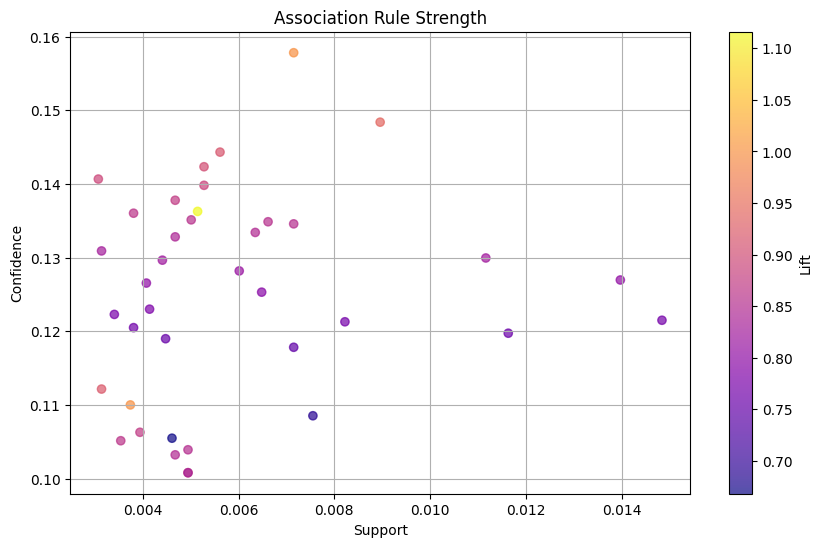

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(Rules['support'], Rules['confidence'], c=Rules['lift'], cmap='plasma', alpha=0.7)
plt.colorbar(label='Lift')
plt.xlabel('Support')
plt.ylabel('Confidence')
plt.title('Association Rule Strength')
plt.grid(True)
plt.show()